In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras import layers, models,callbacks
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
import sys
sys.modules['polars'] = None

## Preprocessing steps

In [127]:
df = pd.read_csv('AAPL.csv')
df.head()

print(df.isnull().sum())
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

df


Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600
...,...,...,...,...,...,...,...
10404,2022-03-18,160.509995,164.479996,159.759995,163.979996,163.979996,123351200
10405,2022-03-21,163.509995,166.350006,163.009995,165.380005,165.380005,95811400
10406,2022-03-22,165.509995,169.419998,164.910004,168.820007,168.820007,81532000
10407,2022-03-23,167.990005,172.639999,167.649994,170.210007,170.210007,98062700


In [128]:
corr = df.corr()
corr

,Date,Open,High,Low,Close,Adj Close,Volume
Date,1.000000,0.643417,0.643040,0.643734,0.643339,0.628948,0.174756
Open,0.643417,1.000000,0.999945,0.999928,0.999861,0.999494,-0.189987
High,0.643040,0.999945,1.000000,0.999910,0.999931,0.999589,-0.189387
Low,0.643734,0.999928,0.999910,1.000000,0.999929,0.999547,-0.190955
Close,0.643339,0.999861,0.999931,0.999929,1.000000,0.999641,-0.190182
Adj Close,0.628948,0.999494,0.999589,0.999547,0.999641,1.000000,-0.193284
Volume,0.174756,-0.189987,-0.189387,-0.190955,-0.190182,-0.193284,1.000000


11:49:24 - cmdstanpy - INFO - Chain [1] start processing
11:49:30 - cmdstanpy - INFO - Chain [1] done processing


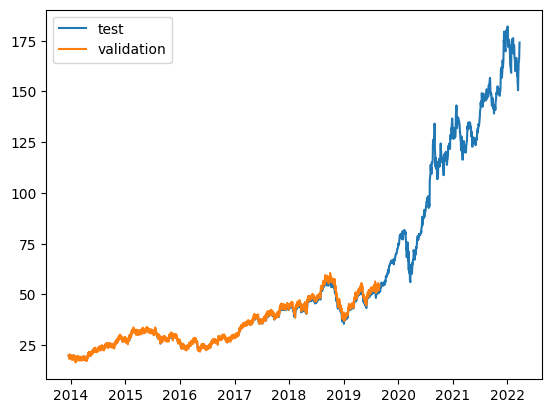

In [129]:
df = df.rename(columns={'Date':'ds', 'Close':'y'})

size = int(len(df) * 0.8)
train = df.iloc[:size]
test = df.iloc[size:]

holidays = pd.DataFrame({
    'holiday':'christmas',
    'ds':pd.to_datetime(["1980-12-25","1981-12-25","2021-12-25"]),
    'lower_window':-1,
    'upper_window':4
})

model = Prophet(holidays=holidays)
model.add_country_holidays(country_name='US')
model.add_regressor('Open')
model.add_regressor('High')
model.add_regressor('Low')
model.add_regressor('Adj Close')
model.add_regressor('Volume',prior_scale=0.001)
model.fit(train)

future = model.make_future_dataframe(periods=len(test), freq='D')
future = future.merge(df[['ds', 'Open','High','Low','Adj Close','Volume']], on = 'ds', how = 'left').ffill().bfill()

forecast = model.predict(future)
pred = forecast[['ds','yhat']].tail(len(test))

plt.plot(test['ds'], test['y'], label = 'test')
plt.plot(pred['ds'],pred['yhat'],label = 'validation')
plt.legend()
plt.show()



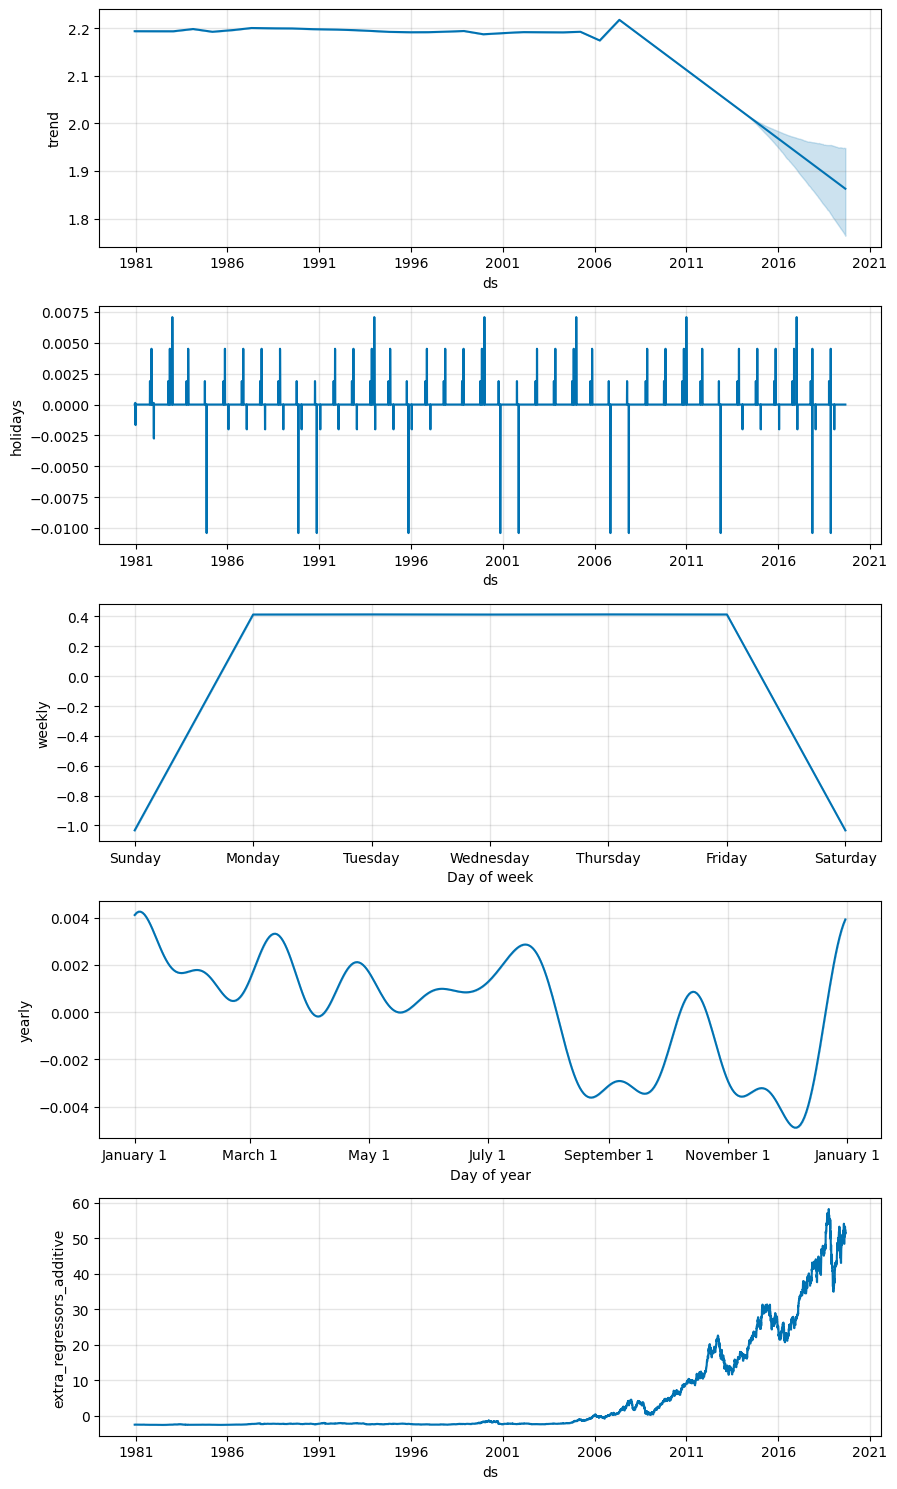

In [130]:
model.plot_components(forecast)
plt.show()

In [131]:
print('mae', mean_absolute_error(test['y'],pred['yhat']))
print('rmse', root_mean_squared_error(test['y'],pred['yhat']))
print('mae', mean_absolute_percentage_error(test['y'],pred['yhat']))

mae 25.70240967157671
rmse 42.44859537976635
mae 0.2981193881444564


## LSTM

In [135]:
df = pd.read_csv('AAPL.csv')
df.head()

df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date',inplace=True)
df.head()

df = df.drop('Date', axis = 1)
df.head()

,Open,High,Low,Close,Adj Close,Volume
0,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
2,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
3,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
4,0.118862,0.119420,0.118862,0.118862,0.092908,73449600


In [136]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df)


def create_sequ(arr):
    x,y = [], []
    for i in range(30, len(arr)):
        x.append(arr[i-30:i])
        y.append(arr[i][3])
    return np.array(x), np.array(y)

x,y = create_sequ(data_scaled)
size = int(len(x) * 0.8)
x_train, x_test = x[:size], x[size:]
y_train, y_test = y[:size], y[size:]


In [137]:
model = tf.keras.Sequential([
    layers.LSTM(64, input_shape = (30, 6)),
    layers.Dropout(0.2),
    layers.Dense(36, activation='relu'),
    layers.Dense(1)
])

early_stops = callbacks.EarlyStopping(monitor='val_loss', patience=3)
model.compile(loss = 'mse', optimizer = 'adam')
history = model.fit(x_train, y_train, epochs = 30, validation_split = 0.2, callbacks = [early_stops])


Epoch 1/30


c:\Users\Midhun P Jose\Desktop\python\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


208/208 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 2.4213e-06 - val_loss: 5.1360e-05
Epoch 2/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 4.9435e-07 - val_loss: 7.0267e-05
Epoch 3/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 4.3291e-07 - val_loss: 1.0756e-05
Epoch 4/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.9261e-07 - val_loss: 2.4129e-05
Epoch 5/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.7112e-07 - val_loss: 1.0617e-04
Epoch 6/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.4445e-07 - val_loss: 1.6533e-04


In [138]:
y_pred = model.predict(x_test)

y_test_inv = scaler.inverse_transform(np.c_[y_test, np.zeros((len(y_pred), df.shape[1] - 1))])[:,0]
y_pre_inv =  scaler.inverse_transform(np.c_[y_pred, np.zeros((len(y_pred), df.shape[1] - 1))])[:,0]

print('mae', mean_absolute_error(y_test_inv, y_pre_inv))
print('rmse', root_mean_squared_error(y_test_inv, y_pre_inv))
print('mape', mean_absolute_percentage_error(y_test_inv, y_pre_inv))


65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
mae 22.249406345288097
rmse 32.00838053637648
mape 0.31141283347649906


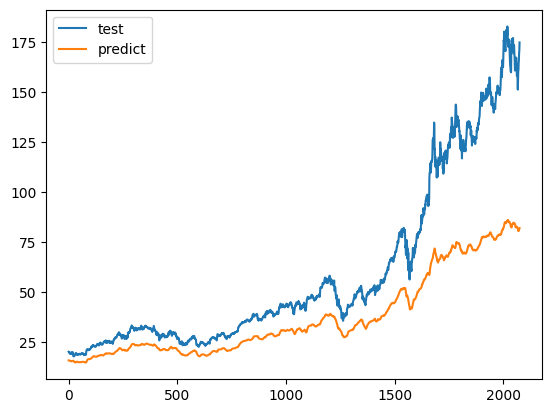

In [139]:
plt.plot(y_test_inv, label = 'test')
plt.plot(y_pre_inv, label = 'predict')
plt.legend()
plt.show()


 Lower Error (MAE & RMSE): The LSTM has a lower Mean Absolute Error (22.25 vs 25.70) and a significantly lower Root Mean Squared Error (32.01 vs 42.45). This means the LSTM's predictions are closer to the actual values on average.
 
 Better Handling of Outliers: The large gap between Prophet's MAE and RMSE (a difference of ~16.7) suggests it struggled with large individual errors. 
 
 The LSTM’s RMSE is much closer to its MAE (a difference of ~9.8), indicating more consistent predictions with fewer extreme misses.Relative Error (MAPE): While the Mean Absolute Percentage Error is slightly higher for the LSTM (31.1% vs 29.8%), this is a marginal difference compared to the substantial gains in absolute accuracy (MAE) and stability (RMSE).
 
 
 Conclusion:The LSTM is superior here because it offers higher precision and is more robust against large errors. Prophet is likely failing to capture specific non-linear patterns or volatilities in your data that the deep learning architecture of the LSTM is successfully learning.